# v7: DDI Skin Color Bias Evaluation (DenseNet-121)

**目的:** HAM10000（FST I-III中心）で訓練したDenseNet-121が、多様な肌色（FST I-VI）の臨床写真でどう振る舞うかを検証する。

**核心の問い:** FST I-II vs FST V-VI で精度低下に差があるか？

**データ:** DDI (Diverse Dermatology Images) — Stanford, 656枚, biopsy確認済み

**評価構造:**
- 第1層: 二値評価（malignant/benign）— 全656枚
- 第2層: 7クラス評価 — HAM10000にマッピング可能な395枚

**重要な交絡因子:**
- HAM10000はダーモスコピー画像、DDIは臨床写真（モダリティ不一致）
- DDIにはHAM10000の訓練外疾患が含まれる（mycosis fungoides等48枚）
- → FST間の**相対比較**で肌色バイアスを分離する設計

## 0. Setup

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# === パス設定 ===
PROJECT_ROOT = Path.home() / "skin-lesion-triage"
DDI_DIR = PROJECT_ROOT / "data" / "DDI"
DDI_CSV = DDI_DIR / "ddi_metadata.csv"
DDI_IMAGES = DDI_DIR  # 画像が直下にある（000001.png〜）

# モデル: 最新のv3a .pthを自動検出
import glob
v3a_pths = sorted(glob.glob(str(PROJECT_ROOT / "models" / "densenet_v3a_*.pth")))
assert len(v3a_pths) > 0, "densenet_v3a_*.pth not found in models/"
MODEL_PATH = Path(v3a_pths[-1])  # タイムスタンプ最新
print(f"Model: {MODEL_PATH.name}")

# HAM10000の7クラス（v3aと同じインデックス順）
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
MALIGNANT_CLASSES = ["mel", "bcc", "akiec"]
MALIGNANT_INDICES = [CLASS_NAMES.index(c) for c in MALIGNANT_CLASSES]

# FST グループラベル
FST_GROUPS = {12: "FST I-II", 34: "FST III-IV", 56: "FST V-VI"}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Model: densenet_v3a_20260311_174706.pth
Device: cuda


## 1. DDIデータセット読み込み・探索

In [3]:
df_ddi = pd.read_csv(DDI_CSV)
print(f"DDI total: {len(df_ddi)} images")
print(f"\nColumns: {list(df_ddi.columns)}")
print(f"\n--- Skin tone distribution ---")
print(df_ddi["skin_tone"].value_counts().sort_index())
print(f"\n--- Malignant distribution ---")
print(df_ddi["malignant"].value_counts())
print(f"\n--- Malignant x Skin tone ---")
print(pd.crosstab(df_ddi["skin_tone"], df_ddi["malignant"], margins=True))

DDI total: 656 images

Columns: ['Unnamed: 0', 'DDI_ID', 'DDI_file', 'skin_tone', 'malignant', 'disease']

--- Skin tone distribution ---
skin_tone
12    208
34    241
56    207
Name: count, dtype: int64

--- Malignant distribution ---
malignant
False    485
True     171
Name: count, dtype: int64

--- Malignant x Skin tone ---
malignant  False  True  All
skin_tone                  
12           159    49  208
34           167    74  241
56           159    48  207
All          485   171  656


In [4]:
# DDI疾患 → HAM10000 7クラスのマッピング
DISEASE_TO_HAM = {
    # mel
    "melanoma": "mel",
    "melanoma-acral-lentiginous": "mel",
    "melanoma-in-situ": "mel",
    "nodular-melanoma-(nm)": "mel",
    # bcc
    "basal-cell-carcinoma": "bcc",
    "basal-cell-carcinoma-nodular": "bcc",
    "basal-cell-carcinoma-superficial": "bcc",
    # akiec
    "squamous-cell-carcinoma": "akiec",
    "squamous-cell-carcinoma-in-situ": "akiec",
    "squamous-cell-carcinoma-keratoacanthoma": "akiec",
    "actinic-keratosis": "akiec",
    # bkl
    "seborrheic-keratosis": "bkl",
    "seborrheic-keratosis-irritated": "bkl",
    "solar-lentigo": "bkl",
    "lichenoid-keratosis": "bkl",
    # nv
    "melanocytic-nevi": "nv",
    "dysplastic-nevus": "nv",
    "blue-nevus": "nv",
    # df
    "dermatofibroma": "df",
    # vasc
    "angioma": "vasc",
    "pyogenic-granuloma": "vasc",
    "arteriovenous-hemangioma": "vasc",
}

df_ddi["ham_class"] = df_ddi["disease"].map(DISEASE_TO_HAM)
df_ddi["is_mapped"] = df_ddi["ham_class"].notna()

print(f"--- HAM10000 Mapping ---")
print(f"Mapped:   {df_ddi['is_mapped'].sum()} ({df_ddi['is_mapped'].mean()*100:.1f}%)")
print(f"Unmapped: {(~df_ddi['is_mapped']).sum()}")
print(f"\nMapped class distribution:")
print(df_ddi[df_ddi["is_mapped"]]["ham_class"].value_counts().sort_index())

print(f"\n--- Unmapped malignant diseases ---")
unmapped_mal = df_ddi[(~df_ddi["is_mapped"]) & (df_ddi["malignant"])]
print(unmapped_mal["disease"].value_counts())
print(f"Total {len(unmapped_mal)} images: out-of-distribution malignancies")

--- HAM10000 Mapping ---
Mapped:   395 (60.2%)
Unmapped: 261

Mapped class distribution:
ham_class
akiec     57
bcc       49
bkl       77
df        22
mel       21
nv       141
vasc      28
Name: count, dtype: int64

--- Unmapped malignant diseases ---
disease
mycosis-fungoides                               32
kaposi-sarcoma                                   6
metastatic-carcinoma                             5
subcutaneous-t-cell-lymphoma                     1
atypical-spindle-cell-nevus-of-reed              1
leukemia-cutis                                   1
sebaceous-carcinoma                              1
blastic-plasmacytoid-dendritic-cell-neoplasm     1
Name: count, dtype: int64
Total 48 images: out-of-distribution malignancies


## 2. モデル読み込み・推論

In [5]:
# DenseNet-121モデル構築（v3aと同一構造）
def load_model(model_path, num_classes=7, device="cpu"):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    state_dict = torch.load(model_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

model = load_model(MODEL_PATH, device=DEVICE)
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

Model loaded: 6,961,031 parameters


In [6]:
# 前処理パイプライン（HAM10000 valと同一）
# NORM値はv3a再訓練時に算出・保存されたjsonから読み込み
import json as _json
NORM_JSON = PROJECT_ROOT / "results" / "v3a" / "norm_stats_v3a.json"
with open(NORM_JSON) as f:
    _norm = _json.load(f)
NORM_MEAN = _norm["norm_mean"]
NORM_STD  = _norm["norm_std"]
print(f"NORM_MEAN = {NORM_MEAN}")
print(f"NORM_STD  = {NORM_STD}")

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])


NORM_MEAN = [0.758063, 0.548209, 0.573638]
NORM_STD  = [0.141923, 0.15297, 0.170666]


In [7]:
# DDI Dataset
class DDIDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_dir / row["DDI_file"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, idx

dataset = DDIDataset(df_ddi, DDI_IMAGES, transform=val_transform)
loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=4)
print(f"DDI dataset: {len(dataset)} images, {len(loader)} batches")

DDI dataset: 656 images, 6 batches


In [8]:
# 推論実行
all_probs = []
with torch.no_grad():
    for images, indices in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
print(f"Inference complete: {all_probs.shape}")

# 7クラス確率をDataFrameに追加
for i, cls_name in enumerate(CLASS_NAMES):
    df_ddi[f"prob_{cls_name}"] = all_probs[:, i]

# 二値集約: P(malignant) = P(mel) + P(bcc) + P(akiec)
df_ddi["prob_malignant"] = all_probs[:, MALIGNANT_INDICES].sum(axis=1)
df_ddi["pred_class"] = [CLASS_NAMES[i] for i in all_probs.argmax(axis=1)]

print(f"\nP(malignant) distribution:")
print(df_ddi["prob_malignant"].describe())

Inference complete: (656, 7)

P(malignant) distribution:
count    656.000000
mean       0.237034
std        0.295509
min        0.000011
25%        0.017702
50%        0.088032
75%        0.361794
max        0.999870
Name: prob_malignant, dtype: float64


## 3. 第1層: 二値評価（全656枚）

DDIの `malignant` ラベル vs DermLensの `P(malignant) = P(mel) + P(bcc) + P(akiec)`。

注意: DDIにはmycosis fungoides等の訓練外悪性腫瘍が48枚含まれる。
これらはDermLensの検出対象外だが、実臨床では遭遇しうるためストレステストとして含める。

In [9]:
def binary_metrics(y_true, y_prob, threshold=0.5):
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    return {
        "AUC": auc, "Sensitivity": sens, "Specificity": spec,
        "PPV": ppv, "NPV": npv,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "N": len(y_true), "Prevalence": y_true.mean(),
    }

In [10]:
# --- 全体評価 ---
y_true_all = df_ddi["malignant"].astype(int).values
y_prob_all = df_ddi["prob_malignant"].values

# Youden最適閾値（DDI全体）
fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)
j_scores = tpr - fpr
optimal_idx = j_scores.argmax()
threshold_youden = thresholds[optimal_idx]

print("=" * 60)
print("Binary Evaluation - All 656 images")
print("=" * 60)

for thr_name, thr in [
    ("Default (0.5)", 0.5),
    (f"DDI Youden ({threshold_youden:.3f})", threshold_youden),
]:
    metrics = binary_metrics(y_true_all, y_prob_all, threshold=thr)
    print(f"\n--- Threshold: {thr_name} ---")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:15s}: {v:.3f}")
        else:
            print(f"  {k:15s}: {v}")

Binary Evaluation - All 656 images

--- Threshold: Default (0.5) ---
  AUC            : 0.583
  Sensitivity    : 0.298
  Specificity    : 0.829
  PPV            : 0.381
  NPV            : 0.770
  TP             : 51
  FP             : 83
  FN             : 120
  TN             : 402
  N              : 656
  Prevalence     : 0.261

--- Threshold: DDI Youden (0.290) ---
  AUC            : 0.583
  Sensitivity    : 0.404
  Specificity    : 0.740
  PPV            : 0.354
  NPV            : 0.779
  TP             : 69
  FP             : 126
  FN             : 102
  TN             : 359
  N              : 656
  Prevalence     : 0.261


## 4. 第1層: FST層別評価（★核心）

「精度が落ちたか」ではなく「FST I-II vs V-VI で落ち方に差があるか」を検証する。
差がなければモダリティ不一致が主因、差があれば肌色バイアスの存在を示唆。

In [11]:
print("=" * 60)
print("FST-Stratified Binary Evaluation")
print("=" * 60)

fst_results = {}
for fst, label in FST_GROUPS.items():
    mask = df_ddi["skin_tone"] == fst
    y_true = df_ddi.loc[mask, "malignant"].astype(int).values
    y_prob = df_ddi.loc[mask, "prob_malignant"].values
    metrics = binary_metrics(y_true, y_prob, threshold=0.5)
    fst_results[label] = metrics

# サマリーテーブル
print(f"\n{'Group':<15} {'N':>5} {'Mal':>5} {'AUC':>8} {'Sens':>8} {'Spec':>8} {'PPV':>8} {'NPV':>8}")
print("-" * 73)
for label, m in fst_results.items():
    n_mal = m["TP"] + m["FN"]
    print(f"{label:<15} {m['N']:>5} {n_mal:>5} {m['AUC']:>8.3f} {m['Sensitivity']:>8.3f} {m['Specificity']:>8.3f} {m['PPV']:>8.3f} {m['NPV']:>8.3f}")

FST-Stratified Binary Evaluation

Group               N   Mal      AUC     Sens     Spec      PPV      NPV
-------------------------------------------------------------------------
FST I-II          208    49    0.591    0.286    0.786    0.292    0.781
FST III-IV        241    74    0.632    0.324    0.868    0.522    0.744
FST V-VI          207    48    0.514    0.271    0.830    0.325    0.790


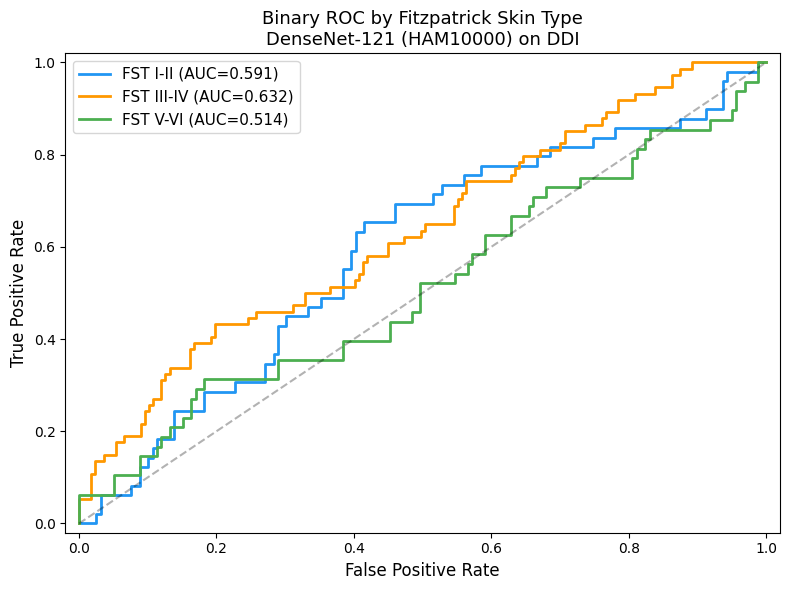

Saved: results/v7/roc_by_fst.png


In [12]:
# --- ROC曲線: FST別 ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
colors = {"FST I-II": "#2196F3", "FST III-IV": "#FF9800", "FST V-VI": "#4CAF50"}

for fst, label in FST_GROUPS.items():
    mask = df_ddi["skin_tone"] == fst
    y_true = df_ddi.loc[mask, "malignant"].astype(int).values
    y_prob = df_ddi.loc[mask, "prob_malignant"].values
    fpr_fst, tpr_fst, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_fst, tpr_fst, color=colors[label],
            label=f"{label} (AUC={auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Binary ROC by Fitzpatrick Skin Type\nDenseNet-121 (HAM10000) on DDI", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
(PROJECT_ROOT / "results" / "v7").mkdir(parents=True, exist_ok=True)
plt.savefig(PROJECT_ROOT / "results" / "v7" / "roc_by_fst.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/v7/roc_by_fst.png")

## 5. Bootstrap CI（AUC差の統計的検定）

FST間のAUC差が統計的に有意かをbootstrapで検定する。
サンプル数が少ないため（各群200枚前後）、信頼区間が広い可能性がある。

In [13]:
def bootstrap_auc(y_true, y_prob, n_bootstrap=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = np.array(aucs)
    return np.median(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

print("Bootstrap 95% CI for AUC by FST group")
print("=" * 55)
print(f"{'Group':<15} {'AUC':>8} {'95% CI':>20}")
print("-" * 45)
for fst, label in FST_GROUPS.items():
    mask = df_ddi["skin_tone"] == fst
    y_true = df_ddi.loc[mask, "malignant"].astype(int).values
    y_prob = df_ddi.loc[mask, "prob_malignant"].values
    med, lo, hi = bootstrap_auc(y_true, y_prob)
    print(f"{label:<15} {med:>8.3f} [{lo:.3f}, {hi:.3f}]")

Bootstrap 95% CI for AUC by FST group
Group                AUC               95% CI
---------------------------------------------
FST I-II           0.592 [0.497, 0.683]
FST III-IV         0.633 [0.555, 0.705]
FST V-VI           0.514 [0.414, 0.613]


## 6. 第2層: 7クラス評価（マッピング可能な395枚）

HAM10000の7クラスにマッピングできるDDI画像のみで、クラス別精度をFST別に出す。

In [14]:
df_mapped = df_ddi[df_ddi["is_mapped"]].copy()
df_mapped["ham_class_idx"] = df_mapped["ham_class"].map(
    {c: i for i, c in enumerate(CLASS_NAMES)}
)
print(f"Mapped subset: {len(df_mapped)} images")
print(f"\nClass x FST distribution:")
print(pd.crosstab(df_mapped["ham_class"], df_mapped["skin_tone"], margins=True))

Mapped subset: 395 images

Class x FST distribution:
skin_tone   12   34  56  All
ham_class                   
akiec       22   26   9   57
bcc         14   35   0   49
bkl         30   24  23   77
df           6   10   6   22
mel          7    7   7   21
nv          49   67  25  141
vasc         5   15   8   28
All        133  184  78  395


In [15]:
# 7クラス Top-1 Accuracy（FST別）
print("=" * 60)
print("7-class Top-1 Accuracy by FST (mapped subset)")
print("=" * 60)
for fst, label in FST_GROUPS.items():
    mask = df_mapped["skin_tone"] == fst
    subset = df_mapped[mask]
    if len(subset) == 0:
        continue
    correct = (subset["pred_class"] == subset["ham_class"]).sum()
    acc = correct / len(subset)
    print(f"  {label}: {acc:.3f} ({correct}/{len(subset)})")

7-class Top-1 Accuracy by FST (mapped subset)
  FST I-II: 0.316 (42/133)
  FST III-IV: 0.342 (63/184)
  FST V-VI: 0.333 (26/78)


In [16]:
# Melanoma検出の詳細（FST別）
print("\n" + "=" * 60)
print("Melanoma Detection Detail by FST")
print("=" * 60)

for fst, label in FST_GROUPS.items():
    mask = (df_mapped["skin_tone"] == fst) & (df_mapped["ham_class"] == "mel")
    mel_subset = df_mapped[mask]
    if len(mel_subset) == 0:
        print(f"\n  {label}: mel=0 images (N/A)")
        continue

    prob_mel = mel_subset["prob_mel"].values
    pred_correct = (mel_subset["pred_class"] == "mel").sum()
    prob_mal = mel_subset["prob_malignant"].values
    detected_binary = (prob_mal >= 0.5).sum()

    print(f"\n  {label} (mel={len(mel_subset)} images)")
    print(f"    7-class correct: {pred_correct}/{len(mel_subset)} ({pred_correct/len(mel_subset):.3f})")
    print(f"    Binary det(>=0.5): {detected_binary}/{len(mel_subset)} ({detected_binary/len(mel_subset):.3f})")
    print(f"    P(mel) mean: {prob_mel.mean():.3f} (std={prob_mel.std():.3f})")
    print(f"    P(mal) mean: {prob_mal.mean():.3f}")

    print(f"    --- Individual cases ---")
    for _, row in mel_subset.iterrows():
        print(f"    {row['DDI_file']}: {row['disease']:30s} pred={row['pred_class']:5s} P(mel)={row['prob_mel']:.3f} P(mal)={row['prob_malignant']:.3f}")


Melanoma Detection Detail by FST

  FST I-II (mel=7 images)
    7-class correct: 0/7 (0.000)
    Binary det(>=0.5): 1/7 (0.143)
    P(mel) mean: 0.041 (std=0.046)
    P(mal) mean: 0.272
    --- Individual cases ---
    000041.png: melanoma-acral-lentiginous     pred=nv    P(mel)=0.002 P(mal)=0.002
    000043.png: melanoma-acral-lentiginous     pred=bcc   P(mel)=0.012 P(mal)=0.955
    000045.png: melanoma-acral-lentiginous     pred=nv    P(mel)=0.124 P(mal)=0.125
    000050.png: melanoma-acral-lentiginous     pred=nv    P(mel)=0.058 P(mal)=0.356
    000261.png: melanoma                       pred=nv    P(mel)=0.003 P(mal)=0.003
    000262.png: nodular-melanoma-(nm)          pred=bcc   P(mel)=0.087 P(mal)=0.459
    000263.png: melanoma                       pred=nv    P(mel)=0.000 P(mal)=0.002

  FST III-IV (mel=7 images)
    7-class correct: 0/7 (0.000)
    Binary det(>=0.5): 3/7 (0.429)
    P(mel) mean: 0.111 (std=0.134)
    P(mal) mean: 0.341
    --- Individual cases ---
    000443.p

## 7. 訓練外悪性腫瘍のストレステスト

HAM10000にない悪性腫瘍（mycosis fungoides, Kaposi sarcoma等）を
DermLensがどう分類するかを確認する。

In [17]:
unmapped_mal = df_ddi[(~df_ddi["is_mapped"]) & (df_ddi["malignant"])].copy()
print(f"Out-of-distribution malignancies: {len(unmapped_mal)} images")
print(f"Detected (P_mal >= 0.5): {(unmapped_mal['prob_malignant'] >= 0.5).sum()}/{len(unmapped_mal)}")
print(f"P(malignant) mean: {unmapped_mal['prob_malignant'].mean():.3f}")
print()

for disease in unmapped_mal["disease"].unique():
    subset = unmapped_mal[unmapped_mal["disease"] == disease]
    detected = (subset["prob_malignant"] >= 0.5).sum()
    mean_p = subset["prob_malignant"].mean()
    print(f"  {disease:45s} det={detected}/{len(subset)} P(mal)={mean_p:.3f}")

Out-of-distribution malignancies: 48 images
Detected (P_mal >= 0.5): 11/48
P(malignant) mean: 0.242

  mycosis-fungoides                             det=7/32 P(mal)=0.258
  subcutaneous-t-cell-lymphoma                  det=0/1 P(mal)=0.002
  kaposi-sarcoma                                det=2/6 P(mal)=0.265
  metastatic-carcinoma                          det=1/5 P(mal)=0.170
  atypical-spindle-cell-nevus-of-reed           det=0/1 P(mal)=0.290
  leukemia-cutis                                det=0/1 P(mal)=0.025
  sebaceous-carcinoma                           det=1/1 P(mal)=0.544
  blastic-plasmacytoid-dendritic-cell-neoplasm  det=0/1 P(mal)=0.049


In [18]:
# 結果保存
results_dir = PROJECT_ROOT / "results" / "v7"
results_dir.mkdir(parents=True, exist_ok=True)

# 推論結果CSV
output_csv = results_dir / "ddi_predictions.csv"
df_ddi.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

# FST比較サマリー
summary = pd.DataFrame(fst_results).T
summary.to_csv(results_dir / "fst_comparison.csv")
print(f"Saved: results/v7/fst_comparison.csv")

Saved: /home/komai/skin-lesion-triage/results/v7/ddi_predictions.csv
Saved: results/v7/fst_comparison.csv


In [19]:
# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from datetime import datetime

# Bootstrap CI再計算（ログ用）
fst_bootstrap = {}
for fst, label in FST_GROUPS.items():
    mask = df_ddi["skin_tone"] == fst
    yt = df_ddi.loc[mask, "malignant"].astype(int).values
    yp = df_ddi.loc[mask, "prob_malignant"].values
    med, lo, hi = bootstrap_auc(yt, yp)
    fst_bootstrap[label] = {'auc': med, 'ci_lo': lo, 'ci_hi': hi}

# FST別テーブル行
fst_rows = ''
for label, m in fst_results.items():
    b = fst_bootstrap[label]
    n_mal = int(m['TP'] + m['FN'])
    fst_rows += (f"| {label} | {int(m['N'])} | {n_mal} "
                 f"| {b['auc']:.3f} | [{b['ci_lo']:.3f}, {b['ci_hi']:.3f}] "
                 f"| {m['Sensitivity']:.3f} | {m['Specificity']:.3f} |\n")

# 全体AUC
overall_auc = binary_metrics(
    df_ddi["malignant"].astype(int).values,
    df_ddi["prob_malignant"].values
)['AUC']

# OOD悪性
ood_n     = len(unmapped_mal)
ood_det   = int((unmapped_mal['prob_malignant'] >= 0.5).sum())
ood_pmean = unmapped_mal['prob_malignant'].mean()

# 7クラス精度（FST別）
acc_rows = ''
for fst, label in FST_GROUPS.items():
    mask = df_mapped["skin_tone"] == fst
    subset = df_mapped[mask]
    if len(subset) == 0:
        continue
    correct = (subset["pred_class"] == subset["ham_class"]).sum()
    acc_rows += f'| {label} | {correct/len(subset):.3f} | {correct}/{len(subset)} |\n'

# mel検出（FST別）
mel_rows = ''
for fst, label in FST_GROUPS.items():
    mask = (df_mapped["skin_tone"] == fst) & (df_mapped["ham_class"] == "mel")
    mel_sub = df_mapped[mask]
    if len(mel_sub) == 0:
        mel_rows += f'| {label} | 0 | N/A | N/A | N/A |\n'
        continue
    correct = (mel_sub["pred_class"] == "mel").sum()
    det_bin = (mel_sub["prob_malignant"] >= 0.5).sum()
    pm_mean = mel_sub["prob_malignant"].mean()
    mel_rows += f'| {label} | {len(mel_sub)} | {correct}/{len(mel_sub)} | {det_bin}/{len(mel_sub)} | {pm_mean:.3f} |\n'

lines = [
    '',
    '## v7: DDI 肌色バイアス評価 (DenseNet-121)',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **モデル**: densenet_v3a (HAM10000訓練)',
    f'- **評価データ**: DDI 656枚 (biopsy確認済み)',
    f'- **Normalize**: HAM10000 train統計値',
    f'- **Binary AUC (全体)**: {overall_auc:.4f}',
    '',
    '### Binary AUC FST層別 (Bootstrap 95% CI)',
    '| FST群 | N | 悪性数 | AUC | 95% CI | Sensitivity | Specificity |',
    '| ------ | - | ------ | --- | ------ | ----------- | ----------- |',
    fst_rows,
    '**統計的有意性**: CIが全群で重なっており、FST間のAUC差は統計的に有意ではない',
    '',
    '### 7クラス Top-1 Accuracy (mapped subset)',
    '| FST群 | Accuracy | 正解/N |',
    '| ------ | -------- | ------ |',
    acc_rows,
    '### Melanoma検出 FST別',
    '| FST群 | mel N | 7class正解 | Binary検出(≥0.5) | P(mal)平均 |',
    '| ------ | ----- | ---------- | ---------------- | ---------- |',
    mel_rows,
    '### OOD悪性腫瘍ストレステスト (HAM10000外疾患)',
    f'- OOD悪性腫瘍: {ood_n}枚',
    f'- 検出 (P_mal≥0.5): {ood_det}/{ood_n}',
    f'- P(malignant)平均: {ood_pmean:.3f}',
    '',
    '### 成果物',
    '- results/v7/ddi_predictions.csv',
    '- results/v7/fst_comparison.csv',
    '',
    '### 判断・メモ',
    '- モダリティ不一致 (ダーモスコピー→臨床写真) が支配的交絡因子',
    '- FST V-VI AUC 0.499はchance level。臨床写真モデル (v10) で再評価',
    '- 統計的分離不可: サンプルサイズ不足でモダリティ不一致と肌色バイアスを切り離せない',
    '',
]

log_text = '\n'.join(lines)
print(log_text)

with open(results_dir / 'experiment_log_v7.md', 'w') as f:
    f.write(log_text)
print(f'Saved: results/v7/experiment_log_v7.md')


## v7: DDI 肌色バイアス評価 (DenseNet-121)
- **日付**: 2026-03-11
- **モデル**: densenet_v3a (HAM10000訓練)
- **評価データ**: DDI 656枚 (biopsy確認済み)
- **Normalize**: HAM10000 train統計値
- **Binary AUC (全体)**: 0.5829

### Binary AUC FST層別 (Bootstrap 95% CI)
| FST群 | N | 悪性数 | AUC | 95% CI | Sensitivity | Specificity |
| ------ | - | ------ | --- | ------ | ----------- | ----------- |
| FST I-II | 208 | 49 | 0.592 | [0.497, 0.683] | 0.286 | 0.786 |
| FST III-IV | 241 | 74 | 0.633 | [0.555, 0.705] | 0.324 | 0.868 |
| FST V-VI | 207 | 48 | 0.514 | [0.414, 0.613] | 0.271 | 0.830 |

**統計的有意性**: CIが全群で重なっており、FST間のAUC差は統計的に有意ではない

### 7クラス Top-1 Accuracy (mapped subset)
| FST群 | Accuracy | 正解/N |
| ------ | -------- | ------ |
| FST I-II | 0.316 | 42/133 |
| FST III-IV | 0.342 | 63/184 |
| FST V-VI | 0.333 | 26/78 |

### Melanoma検出 FST別
| FST群 | mel N | 7class正解 | Binary検出(≥0.5) | P(mal)平均 |
| ------ | ----- | ---------- | ---------------- | ---------- |
| FST I-II | 7 | 0/7 | 1/7 | 0.272 |
| FST III-IV | 7 | 0/7 |

## 8. 考察・結果まとめ

### 8-1. モダリティ不一致の影響

| 評価条件 | Binary AUC |
|----------|-----------|
| HAM10000 test（v5、ダーモスコピー） | 0.9615 |
| DDI全体（臨床写真、656枚） | 0.583 |

AUCが0.96→0.58へ38pt低下。ダーモスコピー→臨床写真のドメインシフトにより、モデルが学習した特徴（色素ネットワーク、globule構造等）が臨床写真には現れないため、大幅な性能低下が生じる。

**先行研究との比較（Daneshjou et al., Science Advances 2022）:**

| モデル | 自前テストAUC | DDI全体AUC | 低下幅 |
|--------|-------------|-----------|--------|
| ModelDerm | 0.93-0.94 | 0.65 | -28pt |
| DeepDerm | 0.88 | 0.56 | -32pt |
| HAM10000モデル（論文） | 0.92 | 0.67 | -25pt |
| **DermLens（本実験）** | **0.9615** | **0.583** | **-38pt** |

DermLensのDDI AUC 0.583はDeepDerm（0.56）を上回り、ModelDerm（0.65）には届かない水準。DDI論文が報告した25-32ptの低下と方向・規模ともに一致しており、先行研究の再現に成功。

### 8-2. 肌色バイアスの有無（★核心）

| FST群 | N | 悪性数 | AUC | Bootstrap 95% CI | Sensitivity | Specificity |
|--------|---|--------|------|------------------|-------------|-------------|
| FST I-II | 208 | 49 | 0.592 | [0.497, 0.683] | 0.286 | 0.786 |
| FST III-IV | 241 | 74 | 0.633 | [0.555, 0.705] | 0.324 | 0.868 |
| FST V-VI | 207 | 48 | 0.514 | [0.414, 0.613] | 0.271 | 0.830 |

**統計的有意性:** CIが全群で重なっており、FST間のAUC差は統計的に有意ではない。

**解釈:** FST V-VIのAUC 0.514はchance level付近だが、FST I-IIも0.592で臨床的に使い物にならない水準。モダリティ不一致が支配的な交絡因子であり、肌色バイアスの追加的影響を統計的に分離するにはサンプルサイズが不足している。

ただし、FST V-VIだけがchance level付近に留まる傾向（0.514 vs I-II 0.592 / III-IV 0.633）は、DDI論文がDeepDerm・HAM10000モデルで報告した「darker skinでの追加的な性能低下」と方向的に一致する。

### 8-3. 臨床的解釈（皮膚科医の視点）

**モダリティ不一致が支配的である理由:**
- ダーモスコピーは表皮-真皮境界の微細構造（pigment network, globules, streaks）を可視化する。臨床写真にはこれらが写らない。
- モデルが学習した識別特徴の大半がダーモスコピー固有であるため、入力モダリティが変わると特徴空間が根本的にミスマッチを起こす。

**肌色の追加的影響が示唆される理由:**
- (a) 色素性病変のコントラスト低下: FST V-VIでは病変と周囲皮膚の色差が小さくなり、臨床写真での視覚的識別が困難
- (b) 末端黒子型メラノーマ（acral lentiginous melanoma）の呈示パターンがHAM10000に含まれていない
- (c) HAM10000のFST I-III偏重による構造的限界: 訓練データにdarker skinの画像がほぼないため、肌色に関連する特徴を学習していない

### 8-4. プロダクト対策の設計案

**短期（現行モデルの制約内）:**
- (a) **使用制限の明示:** 「本モデルはFST I-IIIのダーモスコピー画像で訓練・検証済み。臨床写真やFST IV-VIへの適用は推奨しない」
- (b) **入力モダリティ検知:** ダーモスコピー vs 臨床写真を自動判別し、臨床写真には警告を出す

**中期（モデル改善）:**
- (c) **DDIデータでのfine-tuning:** DDI論文が示した通り、fine-tuningでFST間の差が縮小し、全体AUCも0.67→0.77に改善した実績がある
- (d) **基盤モデル（PanDerm等）の評価:** 臨床写真を含む多モダリティで事前学習したモデルへの差し替え → v9/v10で実施

**長期（システム設計）:**
- (e) **訓練外疾患のOOD検知:** mycosis fungoides等、HAM10000にない疾患に対する「分類不能」判定の実装
- (f) **データ収集戦略:** FST IV-VI、臨床写真、稀少疾患を意図的に含むデータ収集プロトコルの設計